In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('notebook')
from my_fun.my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [34]:
def plot_task_events(events):
    """
    Plot task events as a schematic timeline.
    :param events: List of tuples (name, start, duration, linestyle, color, y)
                   start and duration can be either a float or a list of floats
    """

    # Flatten all start+duration to compute t_max
    all_times = []
    for _, start, duration, _, _, _ in events:
        if isinstance(start, (list, tuple)):
            all_times.extend([s + d for s, d in zip(start, duration)])
        else:
            all_times.append(start + duration)

    t_min = -2.5  # Stimulus load time
    t_max = max(all_times) + 0.5

    for i, (name, start, duration, linestyle, color, y_base) in enumerate(events):
        # Make lists if single values
        if not isinstance(start, (list, tuple)):
            start = [start]
            duration = [duration]

        # Determine indentation for the row (does not change actual start times)
        x_indent = 0.5 if name in ['Correct', 'Error'] else 0

        # Build x and y for all pulses in this row
        x = [t_min + x_indent]
        y = [0]

        for s, d in zip(start, duration):
            if name == 'Spouts':
                ramp = 0.1  # Add short ramps at start and end
                x.extend([s, s + ramp, s + d - ramp, s + d])
                y.extend([0, 1-ramp, 1-ramp, 0])
            else:
                x.extend([s, s, s + d, s + d])
                y.extend([0, 1, 1, 0])
        x.append(t_max)
        y.append(0)

        # y_offset = (len(events) - 1 - i) * 1.5
        row_height = 1.5
        n_rows = max(yb for *_, yb in events) + 1
        y_offset = (n_rows - 1 - y_base) * row_height

        y = [v + y_offset for v in y]

        plt.plot(x, y, linestyle=linestyle, color=color)
        plt.text(t_min + 0.05 + x_indent, y_offset + 0.5, name, va='center', color=color, fontsize=9)

    # Add minor ticks at every integer
    plt.xticks([])
    # ax = plt.gca()
    # ax.set_xticks(range(int(t_min), int(t_max)+1), minor=True)
    # plt.xlabel('Time (s) from stimulus onset')

    plt.yticks([])
    # plt.ylim(-0.5, len(events)*1.5)
    sns.despine(left=True, bottom=True)

# Plot task schematics

## Regular task (Results I)

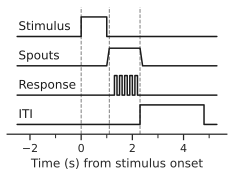

In [6]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 1, 'k'),
    ('Spouts', 1, 1.4, 'k'),
    ('Response', [1.3, 1.5, 1.7, 1.9, 2.1], [0.1, 0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('ITI', 2.3, 2.5, 'k')  # Variable ITI
]

plot_task_events(events)
plt.axvline(0, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset
plt.axvline(1.1, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Go cue
plt.axvline(2.3, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Response
# plt.axvline(4.8, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset

## Drug task (Results II)

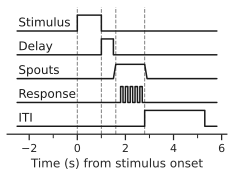

In [169]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 1, 'k'),
    ('Delay', 1, 0.5, 'k'),
    ('Spouts', 1.5, 1.4, 'k'),
    ('Response', [1.8, 2, 2.2, 2.4, 2.6], [0.1, 0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('ITI', 2.8, 2.5, 'k')  # Variable ITI
]

plot_task_events(events)
plt.axvline(0, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset
plt.axvline(1, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Delay
plt.axvline(1.6, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Go cue
plt.axvline(2.8, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Response
# plt.axvline(5.3, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset

## Ephys task (Results III)

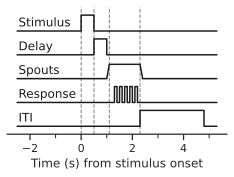

In [7]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 0.5, 'k'),
    ('Delay', 0.5, 0.5, 'k'),
    ('Spouts', 1, 1.4, 'k'),
    ('Response', [1.3, 1.5, 1.7, 1.9, 2.1], [0.1, 0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('ITI', 2.3, 2.5, 'k')  # Variable ITI
]

plot_task_events(events)
plt.axvline(0, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Delay
plt.axvline(1.1, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Go cue
plt.axvline(2.3, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Response
# plt.axvline(4.8, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset

# NMDAR paper

In [19]:
figsize = fig_size(n_cols=3)

## 2ADC task (Tiffany's)

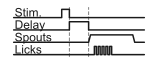

In [33]:
# Define events: (name, start, duration)
events = [
    ('Stim.', 0, 0.4, '-', 'k', 0),
    ('Delay', 0.4, 1, '-', 'k', 1),  # 1 s
    ('Spouts', 1.4, 2.4, '-', 'k', 2),
    ('Licks', [1.7, 1.9, 2.1, 2.3, 2.5], [0.1, 0.1, 0.1, 0.1, 0.1], '-', 'k', 3),  # 5 licks
    # ('ITI', 3.7, 4, '-', 'k', 4)  # Variable ITI
]

plt.figure(figsize=(figsize[0], figsize[1]/2), constrained_layout=True)
plot_task_events(events)
# plt.title('2ADC task')
plt.axvline(0.4, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Go cue
plt.axvline(1.4, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Response

## 2AFC task (Alexis')

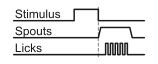

In [32]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 1, '-', 'k', 0),
    ('Spouts', 1, 1.4, '-', 'k', 1),
    ('Licks', [1.3, 1.5, 1.7, 1.9, 2.1], [0.1, 0.1, 0.1, 0.1, 0.1],'-', 'k', 2),  # 5 licks
    # ('ITI', 2.3, 2.5,'-', 'k', 3)  # Variable ITI
]

plt.figure(figsize=(figsize[0], figsize[1]/2), constrained_layout=True)
plot_task_events(events)
# plt.title('2AFC task')
plt.axvline(1, color='tab:gray', linestyle='--', lw=1, zorder=0)  # Go cue

## MCDR task (Balma's)

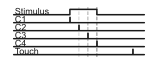

In [38]:
# Define events: (name, start, duration)
events = [
    # ('', 0, 0.4, '--', 'lightgray', 0),
    # ('', 0, 0.8, '--', 'gray', 0),
    ('Stimulus', 0, 1.2, '-', 'k', 0),
    ('C1', 0, 0.01, '-', 'k', 1),
    ('C2', 0.4, 0.01, '-', 'k', 2),
    ('C3', 0.8, 0.01, '-', 'k', 3),
    ('C4', 1.2, 0.01, '-', 'k', 4),
    # ('Photogates', [0, 0.4, 0.8, 1.2], [0.01, 0.01, 0.01, 0.01], '-', 'k'),  # Photogates
    ('Touch', [2.8], [0.01], '-', 'k', 5),  # Touch screen
    # ('Reward', [3.6, 3.8, 4, 4.2, 4.4], [0.1, 0.1, 0.1, 0.1, 0.1], '-', 'k'),  # 5 licks
    # ('ITI', 4.4, 2.5, '-', 'k')  # Variable ITI
]

plt.figure(figsize=(figsize[0], figsize[1]/2), constrained_layout=True)
plot_task_events(events)
# plt.title('MCDR task')
plt.axvline(0.4, color='lightgray', linestyle='--', lw=1, zorder=0)  # Go cue
plt.axvline(0.8, color='darkgray', linestyle='--', lw=1, zorder=0)  # Response
plt.axvline(1.2, color='gray', linestyle='--', lw=1, zorder=0)  # Stimulus onset

# Save all notebook's figures

In [36]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 6 images to notebook_files/
